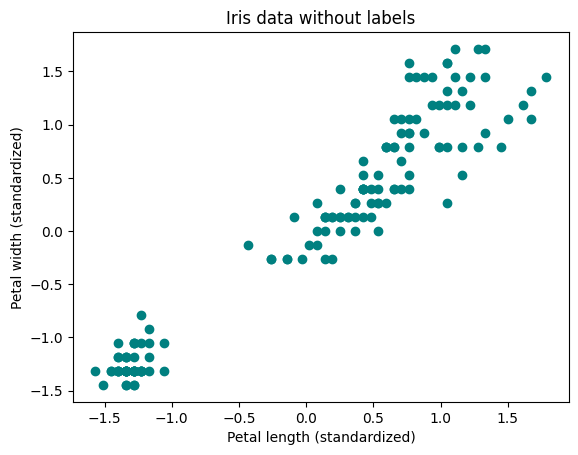

In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

iris = load_iris()

# 꽃잎 길이와 꽃잎 너비만 선택
X = iris.data[:, 2:4]

# 특징값의 크기를 비슷한 기준으로 맞춤
X_scaled = StandardScaler().fit_transform(X)

# 정답 정보 없이 데이터 모양 확인
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], color="teal")
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.title("Iris data without labels")
plt.show()


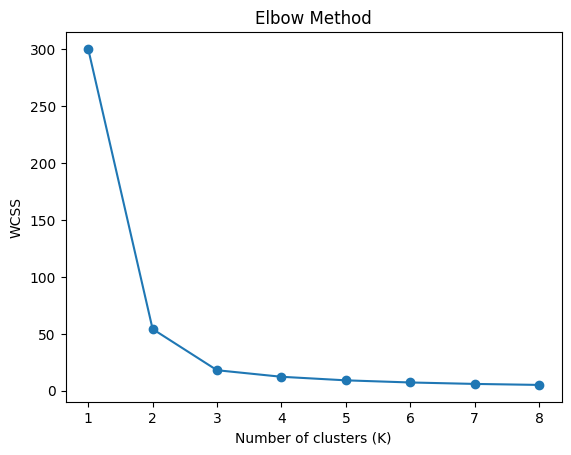

In [2]:
from sklearn.cluster import KMeans

# 각 K값에 대한 WCSS(Within-Cluster Sum of Squares, 군집 내 제곱합)를 저장할 리스트
wcss = []

# K를 1부터 8까지 바꿔가며 KMeans 모델 학습
for k in range(1, 9):
    # n_clusters: 군집 개수
    # random_state: 결과 재현을 위한 난수 시드 고정
    # n_init: 서로 다른 초기 중심점으로 10번 실행 후 가장 좋은 결과 선택
    model = KMeans(n_clusters=k, random_state=42, n_init=10)

    # 표준화된 데이터(X_scaled)로 모델 학습
    model.fit(X_scaled)

    # inertia_: 각 데이터와 소속 군집 중심 사이 거리 제곱의 합(WCSS)
    wcss.append(model.inertia_)

# 엘보우 그래프 시각화: K값에 따른 WCSS 변화 확인
plt.plot(range(1, 9), wcss, marker="o")   # 각 K값 지점에 원형 마커 표시
plt.xlabel("Number of clusters (K)")      # x축: 군집 개수
plt.ylabel("WCSS")                        # y축: 군집 내 제곱합
plt.title("Elbow Method")                 # 그래프 제목
plt.xticks(range(1, 9))                   # x축 눈금을 1~8 정수로 표시
plt.show()

# 해석: WCSS 감소폭이 급격히 줄어드는 '팔꿈치(elbow)' 지점의 K를 최적 군집 수로 선택

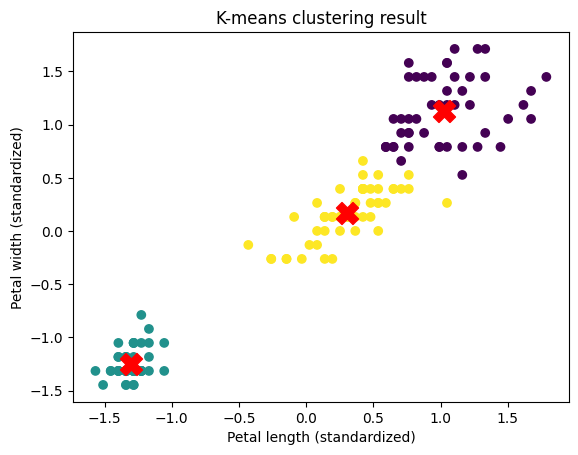

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 엘보우 기법으로 정한 최적 군집 수(K=3)로 KMeans 모델 생성
# random_state: 결과 재현을 위한 난수 시드 고정
# n_init: 서로 다른 초기 중심점으로 10번 실행 후 가장 좋은 결과 선택
model = KMeans(n_clusters=3, random_state=42, n_init=10)

# 모델 학습과 동시에 각 데이터가 속한 군집 번호(0, 1, 2)를 예측
clusters = model.fit_predict(X_scaled)

# 데이터 포인트 산점도: 군집 번호에 따라 색상을 다르게 표시
plt.scatter(
    X_scaled[:, 0],   # x축: 첫 번째 특성 (꽃잎 길이, 표준화)
    X_scaled[:, 1],   # y축: 두 번째 특성 (꽃잎 너비, 표준화)
    c=clusters,       # 군집 번호를 색상 값으로 사용
    cmap="viridis"    # 색상 팔레트 지정
)

# 학습된 각 군집의 중심점 좌표
centers = model.cluster_centers_

# 군집 중심점을 빨간색 X 마커로 표시
plt.scatter(
    centers[:, 0],    # 중심점의 x좌표
    centers[:, 1],    # 중심점의 y좌표
    marker="X",       # X 모양 마커
    s=250,            # 마커 크기 (데이터 포인트보다 크게)
    color="red"       # 중심점 색상
)

# 축 이름 및 제목 설정
plt.xlabel("Petal length (standardized)")   # x축: 표준화된 꽃잎 길이
plt.ylabel("Petal width (standardized)")    # y축: 표준화된 꽃잎 너비
plt.title("K-means clustering result")      # 그래프 제목
plt.show()